/tmp/ipykernel_57051/1143857032.py:49: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label="Predictions")
/tmp/ipykernel_57051/1143857032.py:50: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_train, label="actual")


NameError: name 'y_val' is not defined

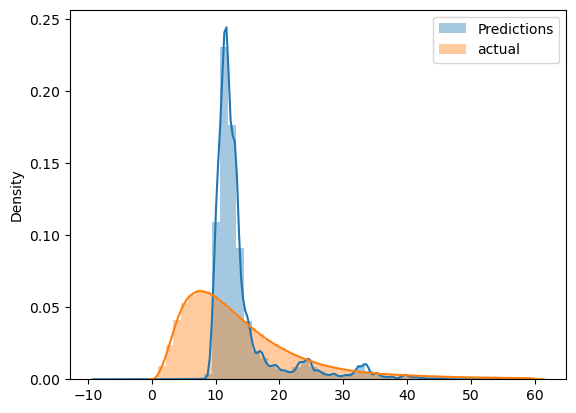

In [1]:
import pandas as pd

# !wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet

df = pd.read_parquet('yellow_tripdata_2025-01.parquet')
df['duration']= df.tpep_dropoff_datetime - df.tpep_pickup_datetime

# change duration to minutes
td = df.duration.iloc[0]

df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

# graph
import seaborn as sns
import matplotlib.pyplot as plt

#sns.distplot(df.duration)

#check data
df.duration.describe(percentiles=[0.99,0.98, 0.97, 0.96, 0.95,0.75,0.50])

df.head().T
df = df[(df.duration >= 1) & (df.duration <= 60)]
categorical = ['PULocationID','DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

from sklearn.feature_extraction import DictVectorizer


train_dicts = df[categorical + numerical].to_dict(orient="records")

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

X_train

target = 'duration'
Y_train = df[target].values
Y_val = df_val[target].values

Y_train

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)

y_pred = lr.predict(X_train)
sns.distplot(y_pred, label="Predictions")
sns.distplot(Y_train, label="actual")

plt.legend()

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_val, y_pred)